In [1]:
import datetime
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
base_path = Path("D:/data/pid-map")
pid_signal = np.fromfile(f"{base_path}/pid_signal.bin", dtype="float")
button_ts = pd.read_csv(f"{base_path}/button_press.csv", header=None, names=["timestamp"])
odor_l_ts = pd.read_csv(f"{base_path}/left_odor_on.csv", header=None, names=["timestamp"])
odor_r_ts = pd.read_csv(f"{base_path}/right_odor_on.csv", header=None, names=["timestamp"])
seq_end = pd.read_csv(f"{base_path}/sequence_end.csv", header=None, names=["timestamp"])
video_ts = pd.read_csv(f"{base_path}/pid_video_ts.csv", header=None, names=["timestamp"])
zero_ts = pd.read_csv(f"{base_path}/zero_ts.csv", header=None, names=["timestamp"])

In [3]:
# Convert datetime to milliseconds
button_ts["timestamp"] = pd.to_datetime(button_ts["timestamp"])
button_ts["timestamp_ms"] = button_ts["timestamp"].astype(np.int64) // 10**6
odor_l_ts["timestamp"] = pd.to_datetime(odor_l_ts["timestamp"])
odor_l_ts["timestamp_ms"] = odor_l_ts["timestamp"].astype(np.int64) // 10**6
odor_r_ts["timestamp"] = pd.to_datetime(odor_r_ts["timestamp"])
odor_r_ts["timestamp_ms"] = odor_r_ts["timestamp"].astype(np.int64) // 10**6
seq_end["timestamp"] = pd.to_datetime(seq_end["timestamp"])
seq_end["timestamp_ms"] = seq_end["timestamp"].astype(np.int64) // 10**6
video_ts["timestamp"] = pd.to_datetime(video_ts["timestamp"])
video_ts["timestamp_ms"] = video_ts["timestamp"].astype(np.int64) // 10**6
zero_ts["timestamp"] = pd.to_datetime(zero_ts["timestamp"])
zero_ts["timestamp_ms"] = zero_ts["timestamp"].astype(np.int64) // 10**6

# Subtract the first timestamp to get relative times
button_ts["relative_time_ms"] = button_ts["timestamp_ms"] - zero_ts["timestamp_ms"].iloc[0]
seq_end["relative_time_ms"] = seq_end["timestamp_ms"] - zero_ts["timestamp_ms"].iloc[0]
odor_l_ts["relative_time_ms"] = odor_l_ts["timestamp_ms"] - zero_ts["timestamp_ms"].iloc[0]
odor_r_ts["relative_time_ms"] = odor_r_ts["timestamp_ms"] - zero_ts["timestamp_ms"].iloc[0]
video_ts["relative_time_ms"] = video_ts["timestamp_ms"] - zero_ts["timestamp_ms"].iloc[0]

In [4]:
len(button_ts)

144

In [5]:
seq_end

,timestamp,timestamp_ms,relative_time_ms
0,2026-05-13 21:01:16.953433600,1778706076953,29493
1,2026-05-13 21:01:51.780620800,1778706111780,64320
2,2026-05-13 21:02:25.153088000,1778706145153,97693
3,2026-05-13 21:03:00.901260800,1778706180901,133441
4,2026-05-13 21:03:39.247961600,1778706219247,171787
...,...,...,...
139,2026-05-13 22:24:18.708902400,1778711058708,5011248
140,2026-05-13 22:24:57.616179200,1778711097616,5050156
141,2026-05-13 22:25:38.161523200,1778711138161,5090701
142,2026-05-13 22:26:14.993280000,1778711174993,5127533


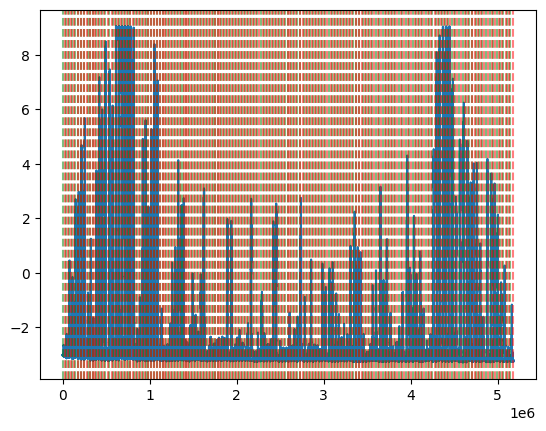

In [6]:
plt.plot(pid_signal)
# Add vertical lines for button presses
for ts in button_ts["relative_time_ms"]:
    plt.axvline(x=ts, color="green", linestyle="--", alpha=0.5)
# Add vertical lines for sequence ends
for ts in seq_end["relative_time_ms"]:
    plt.axvline(x=ts, color="red", linestyle="--", alpha=0.5)
# Add vertical lines for left odor on
# for ts in odor_l_ts["relative_time_ms"]:
#     plt.axvline(x=ts, color="black", linestyle="--", alpha=0.25)
# # Add vertical lines for right odor on
# for ts in odor_r_ts["relative_time_ms"]:
#     plt.axvline(x=ts, color="black", linestyle="--", alpha=0.25)

In [77]:
# Smooth the signal with a Gaussian filter
from scipy.ndimage import gaussian_filter1d
smoothed_signal = gaussian_filter1d(pid_signal, sigma=100)
# Normalize the smoothed signal to the range [0, 1]
smoothed_signal = (smoothed_signal - np.min(smoothed_signal)) / (np.max(smoothed_signal) - np.min(smoothed_signal)) * 100

In [78]:
# Extract signal between button press and sequence end
sequences = []
for _, button_row in button_ts.iterrows():
    button_time = button_row["relative_time_ms"]
    # Find the next sequence end after the button press
    seq_end_row = seq_end[seq_end["relative_time_ms"] > button_time].iloc[0]
    seq_end_time = seq_end_row["relative_time_ms"]
    # Extract the signal for this sequence
    signal_segment = smoothed_signal[button_time:seq_end_time]
    sequences.append(signal_segment)

# Trim sequences to the same length (e.g., 10 seconds = 10000 ms)
max_length = 25000
sequences = [seq[:max_length] for seq in sequences]

Sequence 1 length: 25000 ms
Sequence 2 length: 25000 ms
Sequence 3 length: 25000 ms
Sequence 4 length: 25000 ms
Sequence 5 length: 25000 ms
Sequence 6 length: 25000 ms


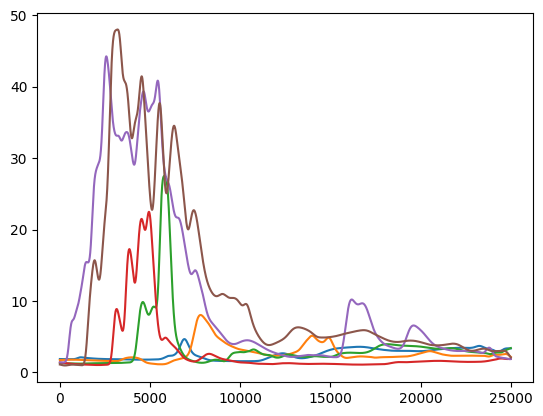

In [79]:
for ii in range(6):
    plt.plot(sequences[ii])
    print(f"Sequence {ii+1} length: {len(sequences[ii])} ms")
plt.title
plt.show()

In [121]:
# Impute missing tile with ones to see where it is in the heatmap
sequences[40] = np.mean([sequences[40-8], sequences[40+8]], axis=0)

In [81]:
np.max(sequences)

100.0

([], [])

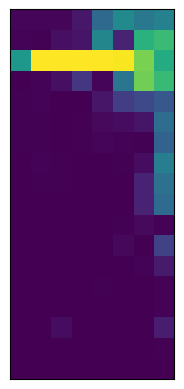

In [122]:
# Generate a heatmap of the sequences at a given timepoint
timepoint = 3000
heatmap_data = np.array([seq[timepoint] for seq in sequences])
# Upsample the heatmap 10x to smooth it out

plt.imshow(heatmap_data.reshape(-1, 8), aspect="equal", cmap="viridis", vmin=np.min(heatmap_data), vmax=100, )
# Set colorbar min and max based on the data range
plt.clim(np.min(sequences), 100)
# Remove ticks and labels
plt.xticks([])
plt.yticks([])
#plt.colorbar(label="PID Signal")

In [124]:
# Downsample the heatmap to 1500 frames (25 seconds at 60 fps)
step = max(1, len(sequences[0]) // 1500)

# Generate a heatmap of the sequences at a given timepoint
for ii, timepoint in enumerate(range(0, len(sequences[0]), step)):
    heatmap_data = np.array([seq[timepoint] for seq in sequences])
    plt.imshow(heatmap_data.reshape(-1, 8), aspect="equal", cmap="viridis", vmin=np.min(heatmap_data), vmax=100, interpolation="bicubic")
    # Set colorbar min and max based on the data range
    plt.clim(np.min(sequences), 100)
    # Remove ticks, labels and axes
    plt.xticks([])
    plt.yticks([])
    plt.axis('off')
    # Save the heatmap as an image file
    plt.savefig(f"{base_path}/visualization/heatmap_{ii}.png", bbox_inches='tight', pad_inches=0)
    plt.close()